<a href="https://colab.research.google.com/github/victorortizrebolloso-cmyk/Risk-Return-Analysis-in-Python/blob/main/risk_return_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install mplfinance

In [4]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import mplfinance as mpf
import plotly.graph_objects as go
import warnings

import yfinance as yf
import missingno as msno

import statsmodels.api as sm

# print(plt.style.available)  # list of available styles
plt.style.use("ggplot")

warnings.simplefilter(action="ignore", category=FutureWarning)

In [5]:
import pandas as pd
import requests
from io import StringIO

# Download the S&P 500 table from Wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

# Extract the ticker symbols
sp500_tickers = pd.read_html(StringIO(html))[0]["Symbol"].tolist()

# Adapt tickers to Yahoo Finance format (e.g. BRK.B -> BRK-B)
sp500_tickers = [ticker.replace(".", "-") for ticker in sp500_tickers]

sp500_tickers

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BE',
 'BNY',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CASY',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COHR',
 'COIN',
 'CL',
 'CMCSA',
 'FIX',
 'COP',
 'E

In [6]:
START = '2024-01-02'
END = '2025-12-31'

In [7]:
stock_sp500 = yf.download(
    sp500_tickers,
    start = START,
    end = END
)['Adj Close']

stock_sp500.head()

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['HONA', 'VYLR', 'FDXF']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-01-02 -> 2025-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1704171600, endDate = 1767157200")')


Ticker,FDXF,HONA,VYLR
Date,,,
2024-01-02,NaN,NaN,NaN
2024-01-03,NaN,NaN,NaN
2024-01-04,NaN,NaN,NaN
2024-01-05,NaN,NaN,NaN
2024-01-08,NaN,NaN,NaN


In [8]:
failed_tickers = ['VYLR', 'HONA', 'FDXF']
tickers = [t for t in sp500_tickers if t not in failed_tickers]

stock_sp500 = yf.download(
    tickers,
    START,
    END,
    auto_adjust = True
)['Close']

stock_sp500.head()

[*********************100%***********************]  500 of 500 completed


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-02,135.917862,183.404007,145.533905,134.479996,103.769424,71.840385,329.828705,580.070007,185.602783,66.223297,...,31.840784,92.002762,57.849815,93.601608,109.875595,72.220001,122.321892,118.228027,267.980011,189.126099
2024-01-03,128.482773,182.030746,146.116684,133.419998,103.457680,73.162132,321.272064,571.789978,181.173187,66.560066,...,31.172680,91.448410,57.950073,94.388031,107.836044,68.629997,122.388260,117.331970,252.520004,185.623901
2024-01-04,128.326050,179.718933,147.027283,133.720001,104.836884,73.666107,320.482971,567.049988,178.402313,65.304024,...,30.742516,91.623466,58.086788,93.565025,108.580330,68.150002,121.999573,117.069016,252.970001,186.691895
2024-01-05,127.895027,178.997726,147.646484,135.979996,104.666855,73.038513,320.036072,564.599976,178.862503,64.448486,...,30.824888,93.023949,58.086788,93.848503,108.406342,66.959999,121.667763,116.854736,252.690002,187.471207
2024-01-08,130.657471,183.324966,146.999969,140.080002,106.178268,73.333298,323.582367,580.549988,181.192368,64.676018,...,31.163521,94.385506,57.950073,92.284828,109.082977,69.309998,121.952171,118.792900,261.089996,188.721954


In [9]:
stock_sp500.shape

(501, 500)

<Axes: >

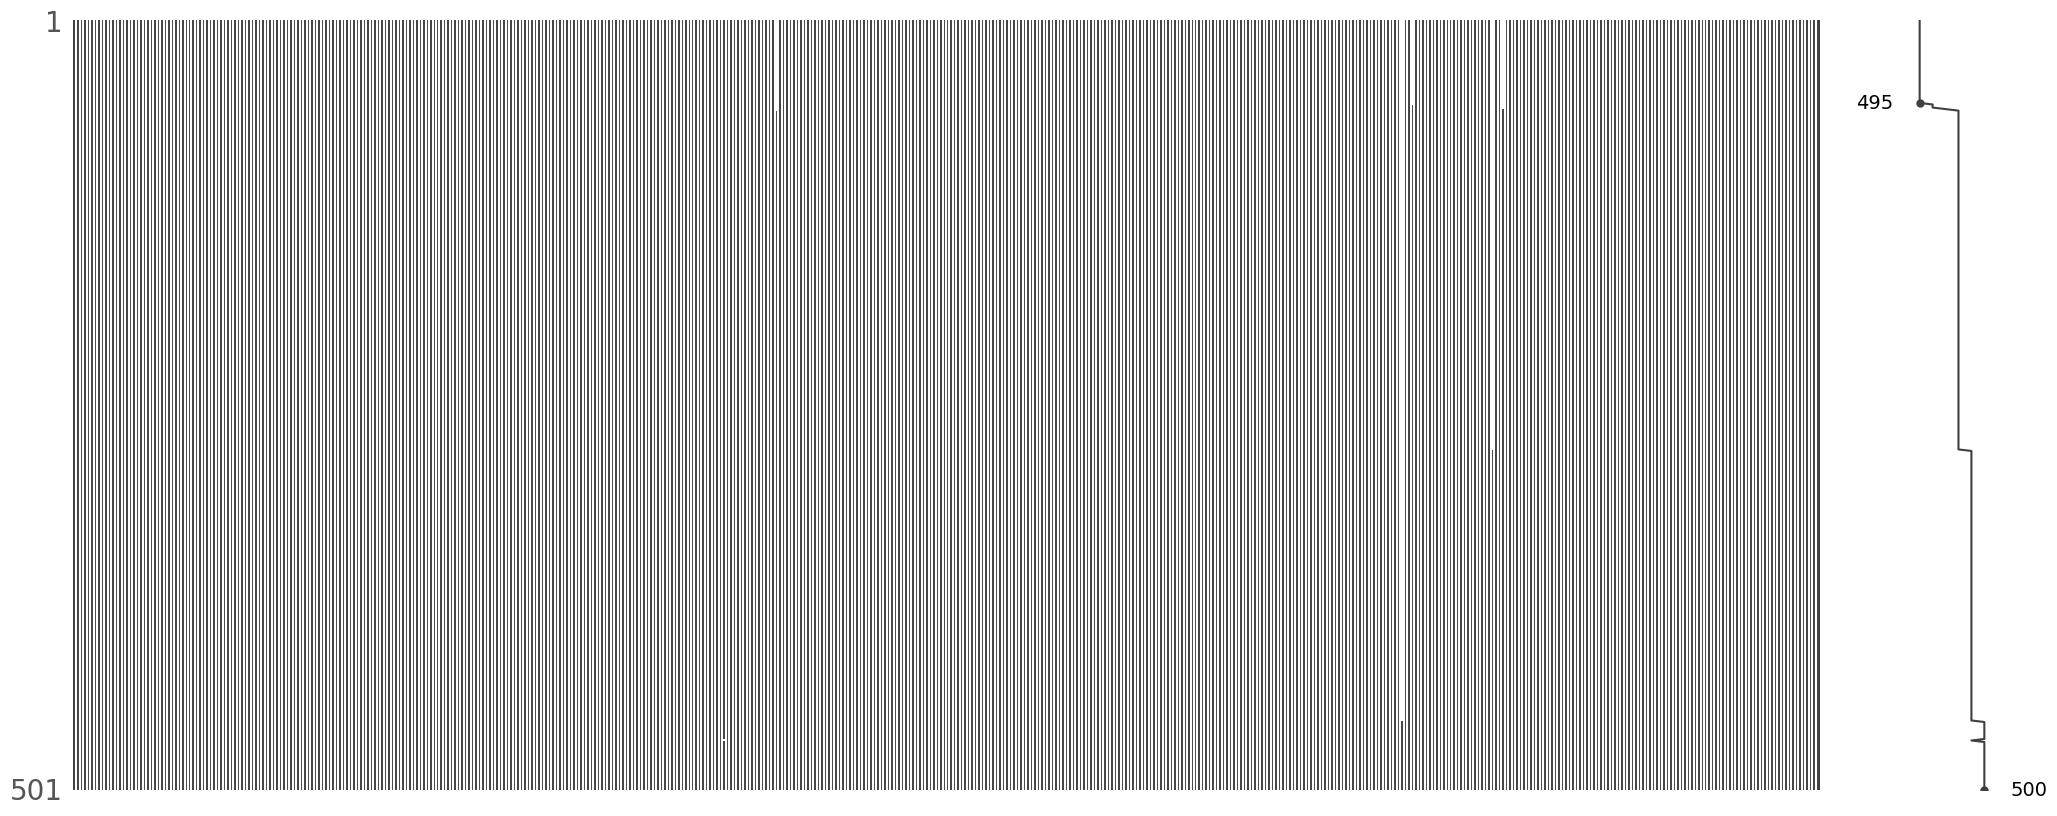

In [10]:
msno.matrix(stock_sp500)

In [11]:
total_nas = stock_sp500.isna().sum().sum()
print(f"Total de valores nulos: {total_nas}")

Total de valores nulos: 909


In [12]:
prices_clean = stock_sp500.dropna(axis = 1, how = 'any')
prices_nas = prices_clean.isna().sum().sum()
print(f"Total de valores nulos: {prices_nas}")

Total de valores nulos: 0


In [13]:
returns = np.log(prices_clean).diff().dropna()
returns.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-03,-0.056256,-0.007516,0.003996,-0.007913,-0.003009,0.018231,-0.026285,-0.014377,-0.024155,0.005072,...,-0.021206,-0.006044,0.001732,0.008367,-0.018737,-0.050987,0.000542,-0.007608,-0.059422,-0.018691
2024-01-04,-0.001221,-0.012781,0.006213,0.002246,0.013243,0.006865,-0.002459,-0.008324,-0.015412,-0.019051,...,-0.013895,0.001912,0.002356,-0.008758,0.006878,-0.007019,-0.003181,-0.002244,0.001780,0.005737
2024-01-05,-0.003364,-0.004021,0.004203,0.016760,-0.001623,-0.008556,-0.001395,-0.004330,0.002576,-0.013187,...,0.002676,0.015170,0.000000,0.003025,-0.001604,-0.017616,-0.002723,-0.001832,-0.001107,0.004166
2024-01-08,0.021369,0.023887,-0.004388,0.029706,0.014337,0.004028,0.011020,0.027858,0.012942,0.003524,...,0.010926,0.014531,-0.002356,-0.016802,0.006222,0.034494,0.002335,0.016450,0.032702,0.006650
2024-01-09,-0.020451,-0.002266,0.005436,-0.003934,0.002932,-0.012658,0.007027,0.009685,0.004119,-0.005503,...,-0.009146,-0.018616,-0.004888,-0.012464,-0.006579,0.003169,-0.003270,-0.000820,-0.017970,-0.001071


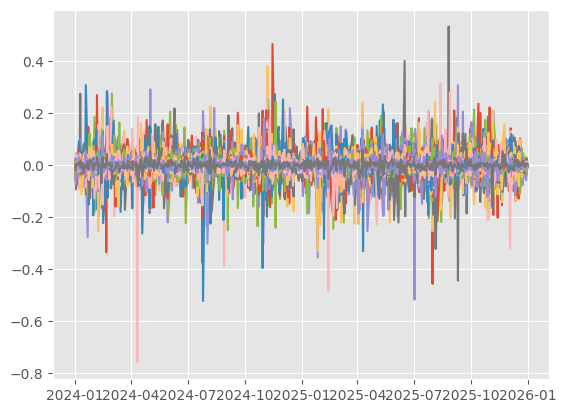

In [14]:
plt.plot(returns)
plt.show()

In [15]:
prices_skewness = prices_clean.skew()
display(prices_skewness.head())
display(prices_skewness.tail())

,0
Ticker,
A,-0.515723
AAPL,0.140482
ABBV,0.558113
ABNB,0.457606
ABT,-0.070953


,0
Ticker,
XYZ,0.419583
YUM,0.245356
ZBH,0.305713
ZBRA,0.356705
ZTS,-0.557737


In [16]:
prices_kurtosis = prices_clean.kurt()
display(prices_kurtosis.head())
display(prices_kurtosis.tail())

,0
Ticker,
A,-0.355881
AAPL,-0.565349
ABBV,-0.607493
ABNB,-0.384271
ABT,-1.421660


,0
Ticker,
XYZ,-0.207080
YUM,-1.017092
ZBH,-0.622907
ZBRA,-0.518995
ZTS,0.029584


In [17]:
valid_skewness = prices_skewness[prices_skewness < 0]
valid_skewness

,0
Ticker,
A,-0.515723
ABT,-0.070953
ACGL,-0.079892
ACN,-0.204085
ADM,-0.171950
...,...
WTW,-0.357813
WY,-0.171086
XOM,-0.628861


In [18]:
# Combined formula
# C_i = 0.5P(K_i) + 0.5P(-S_i)

c_optimum = (0.5 * prices_kurtosis + 0.5 * prices_skewness).sort_values(ascending = False)
c_optimum

,0
Ticker,
LITE,3.932586
EXPD,3.243554
WDC,2.381496
MU,2.312158
BE,2.115262
...,...
DOW,-0.865434
STZ,-0.868514
REG,-0.874986
